# Titanic Survival Analysis

## 📌 About the Project

This project performs Exploratory Data Analysis (EDA) on the Titanic dataset to understand the factors related to passenger survival.

The project includes data cleaning, statistical analysis, and data visualization to identify useful patterns in the dataset.

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset
df = pd.read_csv("Titanic-Dataset.csv")

In [4]:
# View first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Check rows and columns
df.shape

(891, 12)

In [6]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
# Basic statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
# check column name 
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [10]:
# check missing value
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
# check duplicate rows
df.duplicated().sum()

np.int64(0)

In [12]:
# check unique values
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [13]:
# check survival count
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [14]:
# Fill missing Age values
df["Age"] = df["Age"].fillna(df["Age"].median())

In [19]:
# Fill missing Embarked values
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [17]:
# Drop cabin column 
df.drop("Cabin",axis=1,inplace=True)

In [18]:
# check missing values again
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [20]:
# check dataset information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [21]:
# view cleaned data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


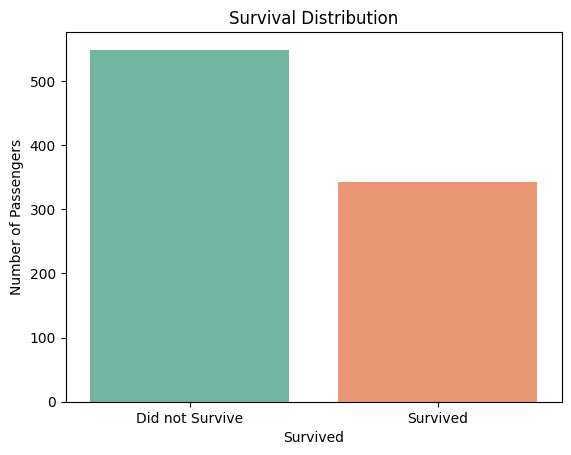

In [23]:
# Survival distribution
sns.countplot(data=df, x="Survived", hue="Survived", palette="Set2", legend=False)

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.xticks([0,1],["Did not Survive","Survived"])

plt.show()

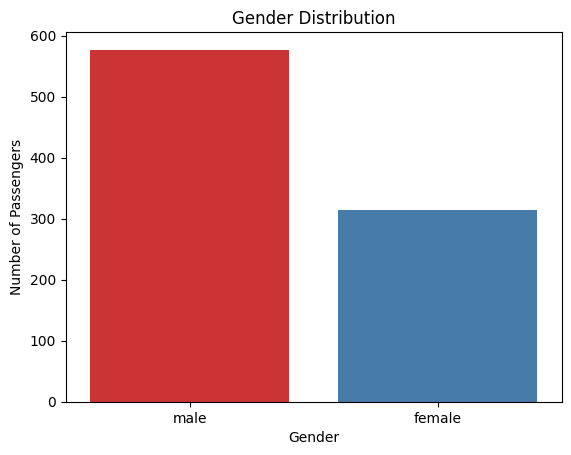

In [26]:
# Gender distribution 
sns.countplot(data=df, x="Sex", hue="Sex", palette="Set1", legend=False)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

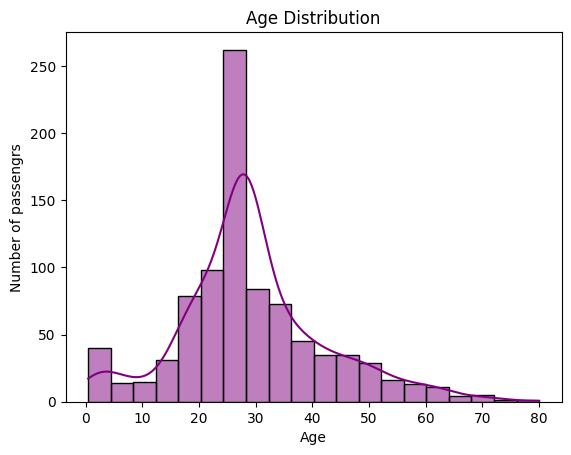

In [27]:
# Age Distribution
sns.histplot(data=df, x="Age", bins=20, kde=True, color="purple")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of passengrs")

plt.show()

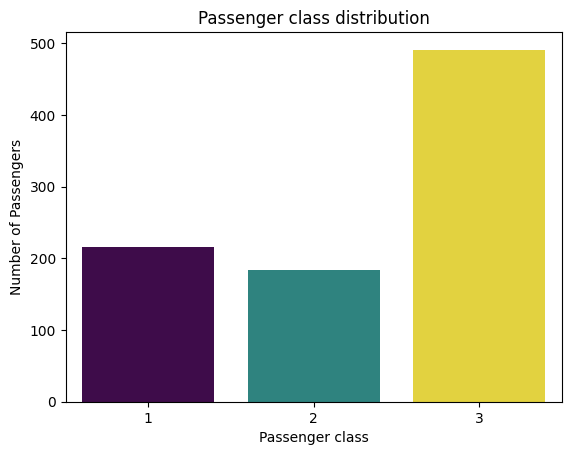

In [31]:
# Passenger class distribution
sns.countplot(data=df, x="Pclass", hue="Pclass", palette="viridis", legend=False)

plt.title("Passenger class distribution")
plt.xlabel("Passenger class")
plt.ylabel("Number of Passengers")

plt.show()

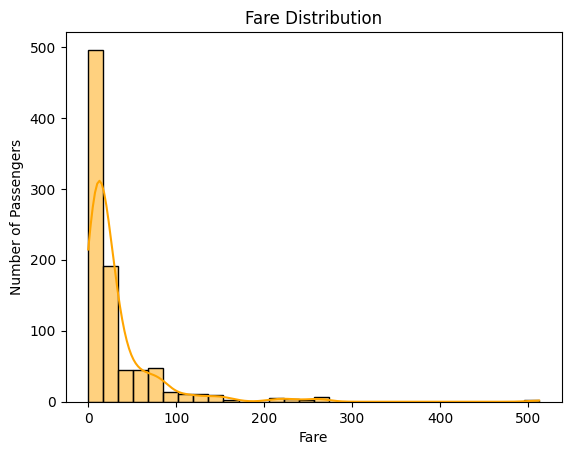

In [33]:
# Fare distribution
sns.histplot(data=df, x="Fare", bins=30, kde=True, color="orange")

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

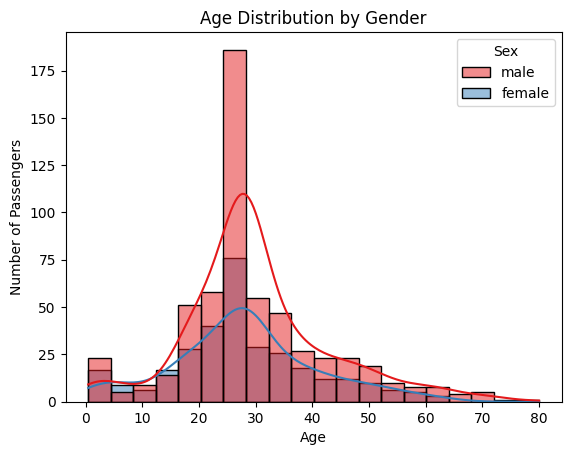

In [35]:
# Age distribution by gender
sns.histplot(data=df, x="Age", hue="Sex", bins=20, kde=True, palette="Set1")

plt.title("Age Distribution by Gender")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

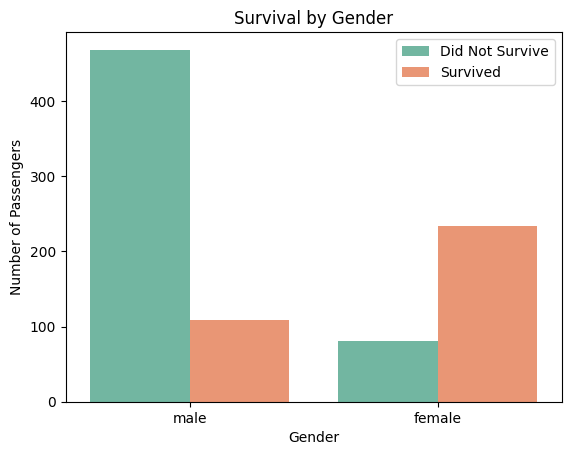

In [38]:
# Survival by gender
sns.countplot(data=df, x="Sex", hue="Survived", palette="Set2")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.legend(["Did Not Survive", "Survived"])

plt.show()

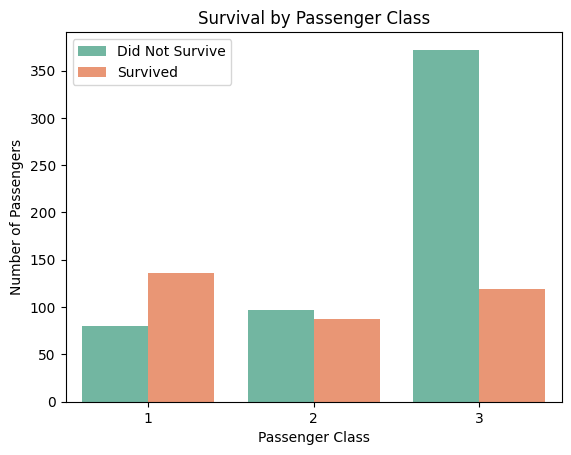

In [39]:
# Survival by passenger class
sns.countplot(data=df, x="Pclass", hue="Survived", palette="Set2")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.legend(["Did Not Survive", "Survived"])

plt.show()

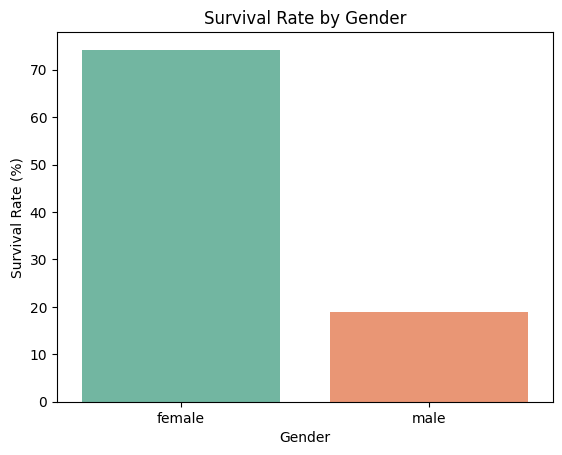

In [40]:
# Survival rate by gender
survival_rate = df.groupby("Sex")["Survived"].mean() * 100

sns.barplot(x=survival_rate.index, y=survival_rate.values, hue=survival_rate.index, palette="Set2", legend=False)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")

plt.show()

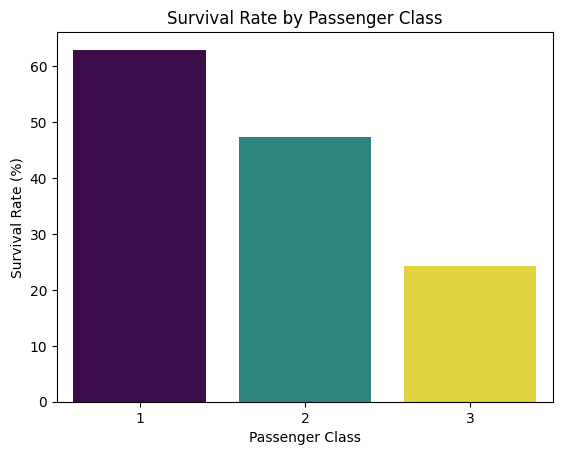

In [41]:
# Survival rate by passenger class
survival_rate = df.groupby("Pclass")["Survived"].mean() * 100

sns.barplot(
    x=survival_rate.index,
    y=survival_rate.values,
    hue=survival_rate.index,
    palette="viridis",
    legend=False
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")

plt.show()

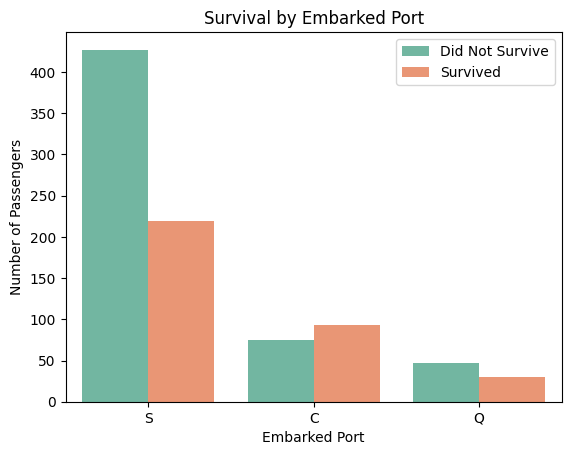

In [42]:
# Survival by embarked port
sns.countplot(data=df, x="Embarked", hue="Survived", palette="Set2")

plt.title("Survival by Embarked Port")
plt.xlabel("Embarked Port")
plt.ylabel("Number of Passengers")

plt.legend(["Did Not Survive", "Survived"])

plt.show()

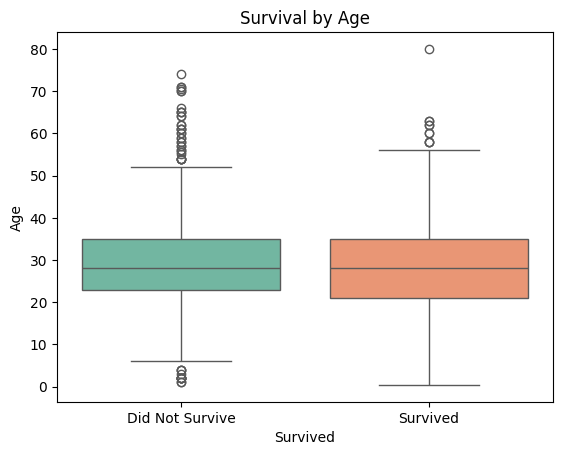

In [44]:
# Survival by age
sns.boxplot(data=df, x="Survived", y="Age", hue="Survived", palette="Set2", legend=False)

plt.title("Survival by Age")
plt.xlabel("Survived")
plt.ylabel("Age")
plt.xticks([0, 1], ["Did Not Survive", "Survived"])

plt.show()

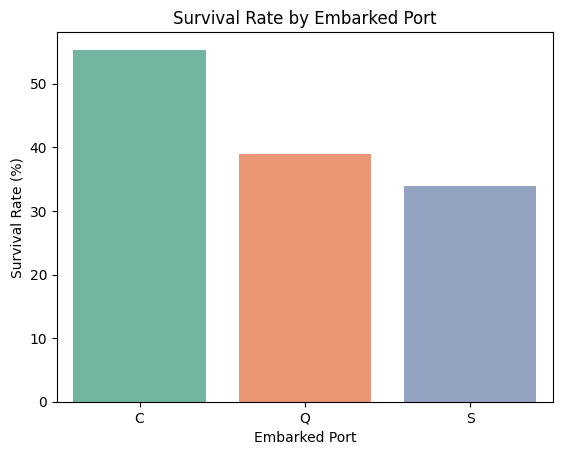

In [45]:
# Survival rate by embarked port
survival_rate = df.groupby("Embarked")["Survived"].mean() * 100

sns.barplot(
    x=survival_rate.index,
    y=survival_rate.values,
    hue=survival_rate.index,
    palette="Set2",
    legend=False
)

plt.title("Survival Rate by Embarked Port")
plt.xlabel("Embarked Port")
plt.ylabel("Survival Rate (%)")

plt.show()

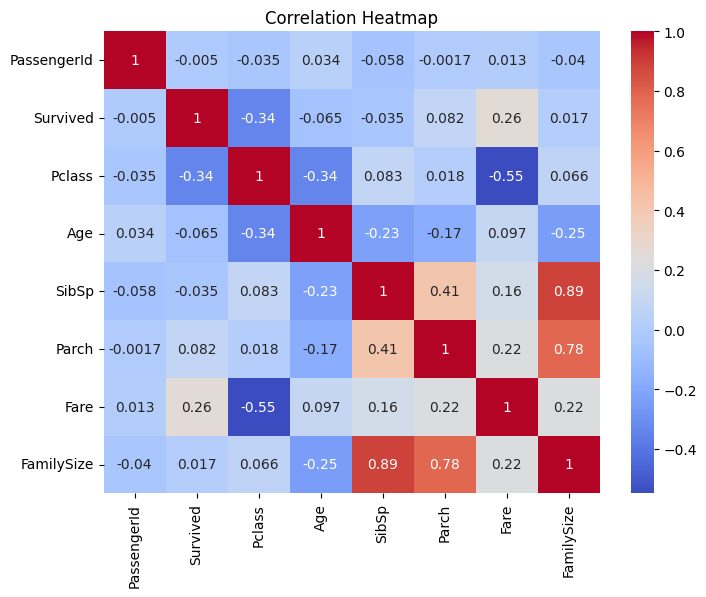

In [46]:
# Correlation heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

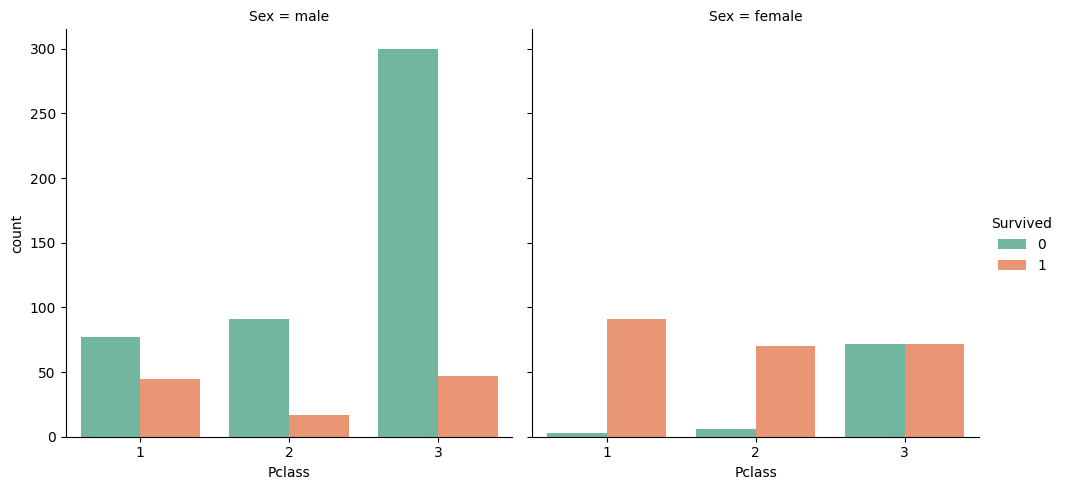

In [47]:
# Survival by gender and class
sns.catplot(
    data=df,
    x="Pclass",
    hue="Survived",
    col="Sex",
    kind="count",
    palette="Set2"
)

plt.show()

## 🔍 Key Findings
1. Survival Rate: A smaller number of passengers survived compared to those who did not survive.
2. Gender: Female passengers had a significantly higher survival rate than male passengers.
3. Passenger Class: First-class passengers had a higher survival rate, while third-class passengers had a lower survival rate.
4. Age: Survival was observed across different age groups, but the age distributions of survivors and non-survivors were different.
5. Fare: Most passengers paid lower fares, while a smaller number of passengers paid very high fares.
6. Embarked Port: Survival rates varied between passengers who boarded from different ports.
7. Overall: Gender and passenger class showed noticeable relationships with passenger survival.

## 📝 Conclusion

The Titanic dataset was analyzed using Exploratory Data Analysis (EDA) techniques.

The analysis showed that factors such as gender and passenger class had a noticeable relationship with passenger survival. Female passengers and passengers from higher classes generally had higher survival rates.

Through data cleaning, statistical analysis, and visualization, useful patterns and relationships in the dataset were identified.

This project helped in understanding the basic EDA process, including data cleaning, visualization, and extracting meaningful insights from data.